In [22]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

In [23]:
# Загрузка датасета и выборка трех классов

CHOSEN_CLASSES = [5, 47, 95]
CLASS_NAMES = ['bed', 'tree', 'whale']
NUM_CLASSES = len(CHOSEN_CLASSES)
DATA_ROOT = './cifar100_data'
OUT_DIR = 'cifar3_dataset'
FORMAT_FILE = 'format.json'

full_train = datasets.CIFAR100(root=DATA_ROOT, train=True, download=True)
full_test  = datasets.CIFAR100(root=DATA_ROOT, train=False, download=True)

if not os.path.exists(OUT_DIR):
    os.makedirs(OUT_DIR)
    for subset, data in [('train', full_train), ('test', full_test)]:
        subset_path = os.path.join(OUT_DIR, subset)
        os.makedirs(subset_path, exist_ok=True)
        for cls_idx in CHOSEN_CLASSES:
            os.makedirs(os.path.join(subset_path, f'class_{cls_idx}'), exist_ok=True)

    for subset, data in [('train', full_train), ('test', full_test)]:
        for img_idx in range(len(data)):
            img, target = data[img_idx]
            if target in CHOSEN_CLASSES:
                save_dir = os.path.join(OUT_DIR, subset, f'class_{target}')
                img.save(os.path.join(save_dir, f'img_{img_idx}.png'), 'png')

    targets = {f'class_{c}': i for i, c in enumerate(CHOSEN_CLASSES)}
    with open(os.path.join(OUT_DIR, FORMAT_FILE), 'w') as f:
        json.dump(targets, f)

C:\Users\laske\AppData\Roaming\Python\Python312\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [24]:
# Класс датасета

class CIFAR3Dataset(Dataset):
    def __init__(self, path, train=True, transform=None):
        self.path = os.path.join(path, 'train' if train else 'test')
        self.transform = transform

        with open(os.path.join(path, FORMAT_FILE), 'r') as f:
            self.format = json.load(f)

        self.length = 0
        self.files = []
        self.targets = torch.eye(NUM_CLASSES)

        for class_dir, internal_id in self.format.items():
            class_path = os.path.join(self.path, class_dir)
            all_files = os.listdir(class_path)
            self.length += len(all_files)
            self.files.extend(
                [(os.path.join(class_path, fname), internal_id) for fname in all_files]
            )

    def __getitem__(self, idx):
        file_path, target = self.files[idx]
        onehot = self.targets[target]
        img = Image.open(file_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, onehot

    def __len__(self):
        return self.length

In [25]:
# Класс сверточной нейронной сети

class CIFAR3CNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        # На вход тензор размером 3x32x32 (Каналы RGB и ширина, высота)
        self.layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),         # 32x32x32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                        # 32x16x16

            nn.Conv2d(32, 64, 3, padding=1),        # 64x16x16
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                        # 64x8x8

            nn.Conv2d(64, 128, 3, padding=1),       # 128x8x8
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)),            # 128x1x1

            nn.Flatten(),                           # 64
            nn.Dropout(0.1),
            nn.Linear(128, num_classes)             # 3
        )

    def forward(self, x):
        return self.layers(x)

In [26]:
# Функция обучения модели
def train_model(model, train_loader, test_loader, epochs, optimizer, scheduler=None):
    loss_fn = nn.CrossEntropyLoss()
    train_losses, test_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for images, labels_onehot in pbar:
            labels = torch.argmax(labels_onehot, dim=1)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

        # Оценка точности на тестовом датасете
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels_onehot in test_loader:
                labels = torch.argmax(labels_onehot, dim=1)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        test_acc = correct / total
        test_accuracies.append(test_acc)

        if scheduler is not None:
            scheduler.step()

        print(f'Epoch {epoch+1}: loss={epoch_loss:.4f}, test accuracy={test_acc:.4f}')

    return train_losses, test_accuracies

In [27]:
# Обучение 

base_transform = transforms.ToTensor()

train_dataset_base = CIFAR3Dataset(OUT_DIR, train=True, transform=base_transform)
test_dataset_base  = CIFAR3Dataset(OUT_DIR, train=False, transform=base_transform)

train_loader_base = DataLoader(train_dataset_base, batch_size=64, shuffle=True)
test_loader_base  = DataLoader(test_dataset_base, batch_size=64, shuffle=False)

model_base = CIFAR3CNN()
optimizer_base = optim.Adam(model_base.parameters(), lr=0.001)

print("Обучение")
train_losses_base, test_acc_base = train_model(
    model_base, train_loader_base, test_loader_base,
    epochs=20, optimizer=optimizer_base
)

Обучение


Epoch 1/20: 100%|██████████| 24/24 [00:01<00:00, 18.75it/s, loss=0.335]


Epoch 1: loss=0.5401, test accuracy=0.7000


Epoch 2/20: 100%|██████████| 24/24 [00:01<00:00, 19.48it/s, loss=0.251]


Epoch 2: loss=0.3739, test accuracy=0.7800


...

Epoch 18: loss=0.1157, test accuracy=0.9400


Epoch 19/20: 100%|██████████| 24/24 [00:01<00:00, 19.09it/s, loss=0.0477]


Epoch 19: loss=0.0862, test accuracy=0.9433


Epoch 20/20: 100%|██████████| 24/24 [00:01<00:00, 19.01it/s, loss=0.161] 


Epoch 20: loss=0.0863, test accuracy=0.8767


In [28]:
# Обучение с аугментацией

aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor()
])

base_transform = transforms.ToTensor()

train_dataset_aug = CIFAR3Dataset(OUT_DIR, train=True, transform=aug_transform)
test_dataset_aug  = CIFAR3Dataset(OUT_DIR, train=False, transform=base_transform)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=64, shuffle=True)
test_loader_aug  = DataLoader(test_dataset_aug, batch_size=64, shuffle=False)

model_aug = CIFAR3CNN()
optimizer_aug = optim.Adam(model_aug.parameters(), lr=0.001)

print("Обучение")
train_losses_aug, test_acc_aug = train_model(
    model_aug, train_loader_aug, test_loader_aug,
    epochs=20, optimizer=optimizer_aug
)

Обучение


Epoch 1/20: 100%|██████████| 24/24 [00:01<00:00, 15.84it/s, loss=0.259]


Epoch 1: loss=0.5417, test accuracy=0.5633


Epoch 2/20: 100%|██████████| 24/24 [00:01<00:00, 16.42it/s, loss=0.297]


Epoch 2: loss=0.3738, test accuracy=0.6533


...

Epoch 18: loss=0.1656, test accuracy=0.8533


Epoch 19/20: 100%|██████████| 24/24 [00:01<00:00, 18.07it/s, loss=0.198] 


Epoch 19: loss=0.1615, test accuracy=0.8833


Epoch 20/20: 100%|██████████| 24/24 [00:01<00:00, 18.00it/s, loss=0.2]   


Epoch 20: loss=0.1234, test accuracy=0.9133


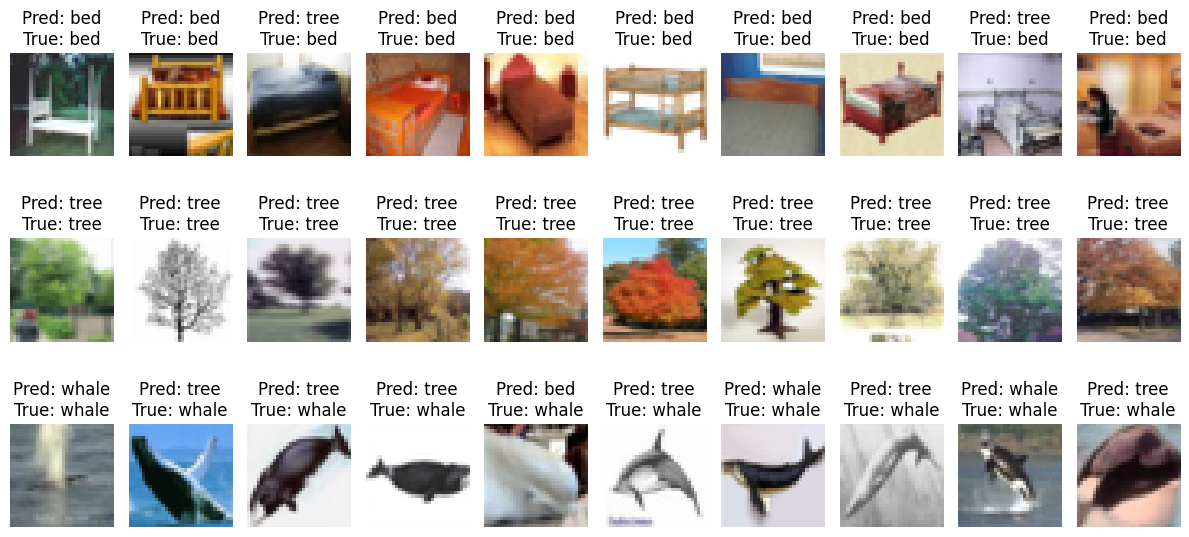

In [29]:
# Вывод нескольких тестовых изображений

model_base.eval()
indices = [
    3, 11, 21, 33, 45, 55, 65, 75, 85, 95,
    105, 115, 121, 132, 145, 155, 162, 176, 180, 199,
    202, 215, 221, 235, 243, 255, 263, 276, 288, 293
]
fig, axes = plt.subplots(3, 10, figsize=(12, 6))
axes = axes.flatten()

for i, idx in enumerate(indices):
    if idx >= len(test_dataset_base):
        break
    img_tensor, label_onehot = test_dataset_base[idx]
    img_batch = img_tensor.unsqueeze(0)

    with torch.no_grad():
        output = model_base(img_batch)
        pred = torch.argmax(output, dim=1).item()
    true_label = torch.argmax(label_onehot).item()

    # Транспонируем каналы для отображения (C,H,W) -> (H,W,C)
    img_show = img_tensor.permute(1, 2, 0)
    axes[i].imshow(img_show)
    axes[i].set_title(f'Pred: {CLASS_NAMES[pred]}\nTrue: {CLASS_NAMES[true_label]}')
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [30]:
print(f"Точность: {test_acc_base[-1]:.4f}")

Точность: 0.8767


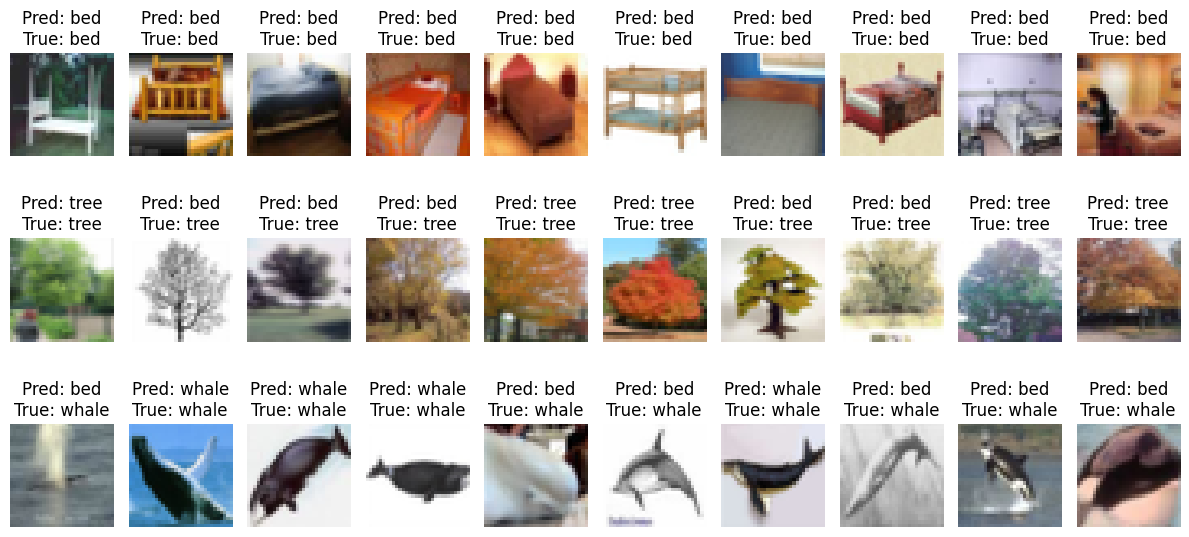

In [31]:
# Вывод нескольких тестовых изображений

model_base.eval()
indices = [
    3, 11, 21, 33, 45, 55, 65, 75, 85, 95,
    105, 115, 121, 132, 145, 155, 162, 176, 180, 199,
    202, 215, 221, 235, 243, 255, 263, 276, 288, 293
]
fig, axes = plt.subplots(3, 10, figsize=(12, 6))
axes = axes.flatten()

for i, idx in enumerate(indices):
    if idx >= len(test_dataset_aug):
        break
    img_tensor, label_onehot = test_dataset_aug[idx]
    img_batch = img_tensor.unsqueeze(0)

    with torch.no_grad():
        output = model_aug(img_batch)
        pred = torch.argmax(output, dim=1).item()
    true_label = torch.argmax(label_onehot).item()

    # Транспонируем каналы для отображения (C,H,W) -> (H,W,C)
    img_show = img_tensor.permute(1, 2, 0)
    axes[i].imshow(img_show)
    axes[i].set_title(f'Pred: {CLASS_NAMES[pred]}\nTrue: {CLASS_NAMES[true_label]}')
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [32]:
print(f"Точность: {test_acc_aug[-1]:.4f}")

Точность: 0.9133
